In [58]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [59]:
# config
TICKER = "SPY"
START = "1993-01-01"   # SPY inception year
END = None            # None = today
MA_WINDOW = 365       # MA_WINDOW-day moving average
COST_BPS_PER_TRADE = 0  # 1 bp per entry/exit

# load df
df = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)
if df.empty:
    raise RuntimeError("No data downloaded. Check ticker/internet/settings.")

# make px a string
adj = df["Adj Close"]

if isinstance(adj, pd.DataFrame):
    if "SPY" in adj.columns:
        px = adj["SPY"]
    else:
        px = adj.iloc[:, 0]
else:
    px = adj

px = px.dropna().rename("px")

In [ ]:
# 1-0 buy-sell strategy

# --- Signal and position (NO lookahead) ---
# Signal formed at end of day t using px[t] and SMA[t]
sma = px.rolling(MA_WINDOW).mean()
signal = (px > sma).astype(int)

# Trade at next bar: position held on day t is based on signal[t-1]
pos = signal.shift(1).fillna(0).astype(int)



=== Metrics ===
Ann. Return (Strategy)        :  9.11%
Ann. Vol (Strategy)           :  13.12%
Sharpe (Strategy)             :  0.730
Max Drawdown (Strategy)       : -28.20%
Ann. Return (Buy&Hold)        :  10.71%
Ann. Vol (Buy&Hold)           :  18.63%
Sharpe (Buy&Hold)             :  0.640
Max Drawdown (Buy&Hold)       : -55.19%
Trades per Year (Strategy)    :  3.069
Time in Market (Strategy)     :  77.47%


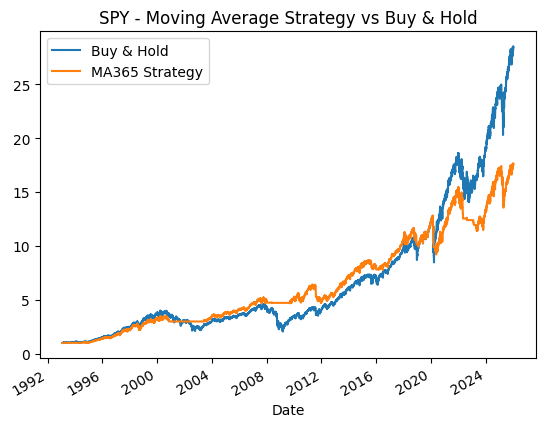

In [61]:
# compute returns
ret = px.pct_change().fillna(0.0)

# --- Transaction costs ---
# Cost incurred when position changes (enter/exit). For daily data, model as bps on notional.
# Each time abs(pos[t]-pos[t-1]) == 1 => one trade (either entry or exit).
trades = pos.diff().abs().fillna(0)
cost = trades * (COST_BPS_PER_TRADE / 10_000.0)

# --- Strategy returns ---
strat_ret = pos * ret - cost

# --- Equity curves ---
eq_buyhold = (1 + ret).cumprod()
eq_strat = (1 + strat_ret).cumprod()

# --- Metrics helpers ---
def max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return dd.min()

def annualized_return(daily_ret: pd.Series, periods=252) -> float:
    # geometric annualized return
    equity = (1 + daily_ret).cumprod()
    n = len(equity)
    if n == 0:
        return np.nan
    return equity.iloc[-1] ** (periods / n) - 1

def annualized_vol(daily_ret: pd.Series, periods=252) -> float:
    return daily_ret.std() * np.sqrt(periods)

def sharpe(daily_ret: pd.Series, rf=0.0, periods=252) -> float:
    # simple Sharpe with rf=0; you can subtract daily rf if you want
    vol = daily_ret.std()
    if vol == 0:
        return np.nan
    return (daily_ret.mean() - rf / periods) / vol * np.sqrt(periods)

def turnover(trades: pd.Series) -> float:
    # average trades per year
    return trades.sum() / (len(trades) / 252)

# --- Compute metrics ---
metrics = {
    "Ann. Return (Strategy)": annualized_return(strat_ret),
    "Ann. Vol (Strategy)": annualized_vol(strat_ret),
    "Sharpe (Strategy)": sharpe(strat_ret),
    "Max Drawdown (Strategy)": max_drawdown(eq_strat),
    "Ann. Return (Buy&Hold)": annualized_return(ret),
    "Ann. Vol (Buy&Hold)": annualized_vol(ret),
    "Sharpe (Buy&Hold)": sharpe(ret),
    "Max Drawdown (Buy&Hold)": max_drawdown(eq_buyhold),
    "Trades per Year (Strategy)": turnover(trades),
    "Time in Market (Strategy)": pos.mean(),
}

print("\n=== Metrics ===")
for k, v in metrics.items():
    if "Drawdown" in k:
        print(f"{k:30s}: {v: .2%}")
    elif "Return" in k or "Vol" in k or "Time" in k:
        print(f"{k:30s}: {v: .2%}")
    else:
        print(f"{k:30s}: {v: .3f}")

# --- Plot ---
plt.figure()
eq_buyhold.plot(label="Buy & Hold")
eq_strat.plot(label=f"MA{MA_WINDOW} Strategy")
plt.title(f"{TICKER} - Moving Average Strategy vs Buy & Hold")
plt.legend()
plt.show()